# Data Preaparation

In [17]:
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
import numpy as np


EXPERIMENT_DIR = "../experiment"  # adjust if needed
pattern = os.path.join(EXPERIMENT_DIR, "scenario*.csv")

BONUS_DIR = "../experiment"
bonus_pattern = os.path.join(BONUS_DIR, "bonus-scenario*.csv")


In [18]:
dfs = []
for fp in glob.glob(pattern):
    m = re.search(r"scenario(\d+)\.csv", os.path.basename(fp))
    scenario = int(m.group(1)) if m else None
    
    df = pd.read_csv(fp)
    df["scenario"] = scenario
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(all_df)} rows from {len(dfs)} files.")

# Keep only completed vehicles
all_df = all_df[all_df["type"] == "Vehicle"].copy()
all_df["duration"] = pd.to_numeric(all_df["duration"], errors="coerce")
all_df = all_df.dropna(subset=["duration"])

print(f"After filtering, {len(all_df)} rows remain.")

# Replication-level means
rep_df = (all_df
          .groupby(["scenario", "seed", "iteration"], as_index=False)
          .agg(mean_duration=("duration", "mean")))

# Scenario-level mean
scenario_summary = (rep_df
                    .groupby("scenario", as_index=False)
                    .agg(avg_trip_time=("mean_duration", "mean")))

scenario_summary

Loaded 122973 rows from 9 files.
After filtering, 122973 rows remain.


,scenario,avg_trip_time
0,0,288.000000
1,1,288.000000
2,2,288.000000
3,3,291.617634
4,4,291.617634
5,5,367.875886
6,6,439.641965
7,7,469.630482
8,8,611.026130


# Results Visualization: Average Trip Time by Scenario

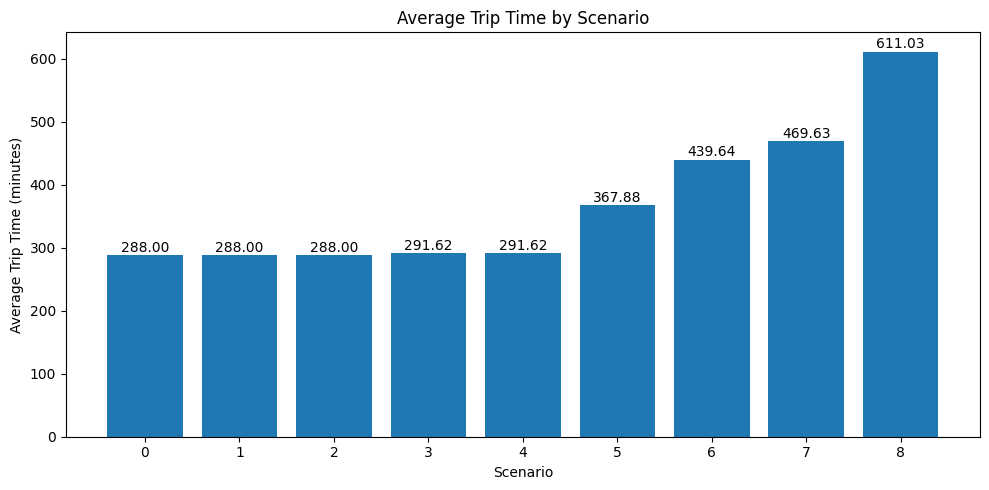

In [19]:
scenario_summary = scenario_summary.sort_values("scenario")

plt.figure(figsize=(10,5))

plt.bar(scenario_summary["scenario"],
        scenario_summary["avg_trip_time"])

# Force all scenario numbers to appear
plt.xticks(scenario_summary["scenario"])

# Add value labels
for i, row in scenario_summary.iterrows():
    plt.text(row["scenario"],
             row["avg_trip_time"] + 5,
             f"{row['avg_trip_time']:.2f}",
             ha='center')

plt.xlabel("Scenario")
plt.ylabel("Average Trip Time (minutes)")
plt.title("Average Trip Time by Scenario")
plt.tight_layout()
plt.show()

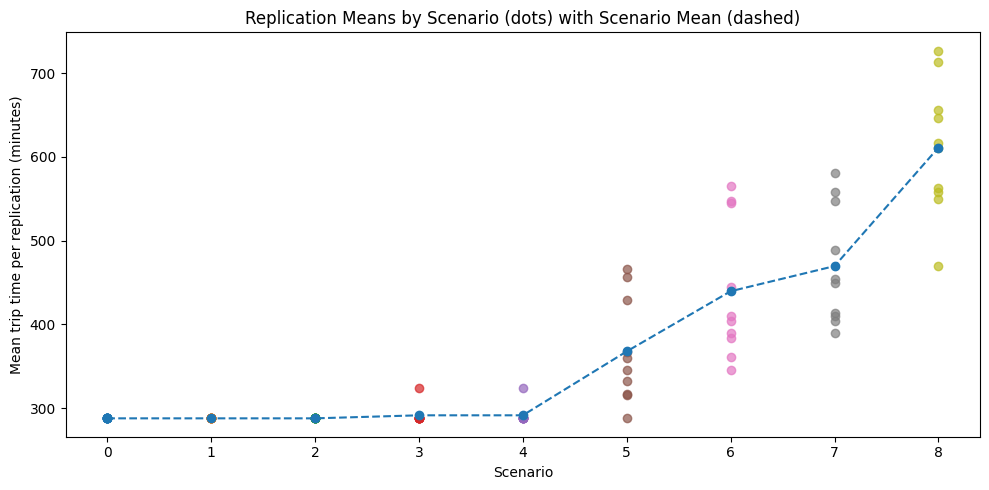

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

scenarios = sorted(rep_df["scenario"].unique())
for s in scenarios:
    y = rep_df.loc[rep_df["scenario"] == s, "mean_duration"].values
    x = [s]*len(y)
    plt.scatter(x, y, alpha=0.7)

# overlay scenario means
means = rep_df.groupby("scenario")["mean_duration"].mean()
plt.plot(means.index, means.values, marker='o', linestyle='--')

plt.xticks(scenarios)
plt.xlabel("Scenario")
plt.ylabel("Mean trip time per replication (minutes)")
plt.title("Replication Means by Scenario (dots) with Scenario Mean (dashed)")
plt.tight_layout()
plt.show()

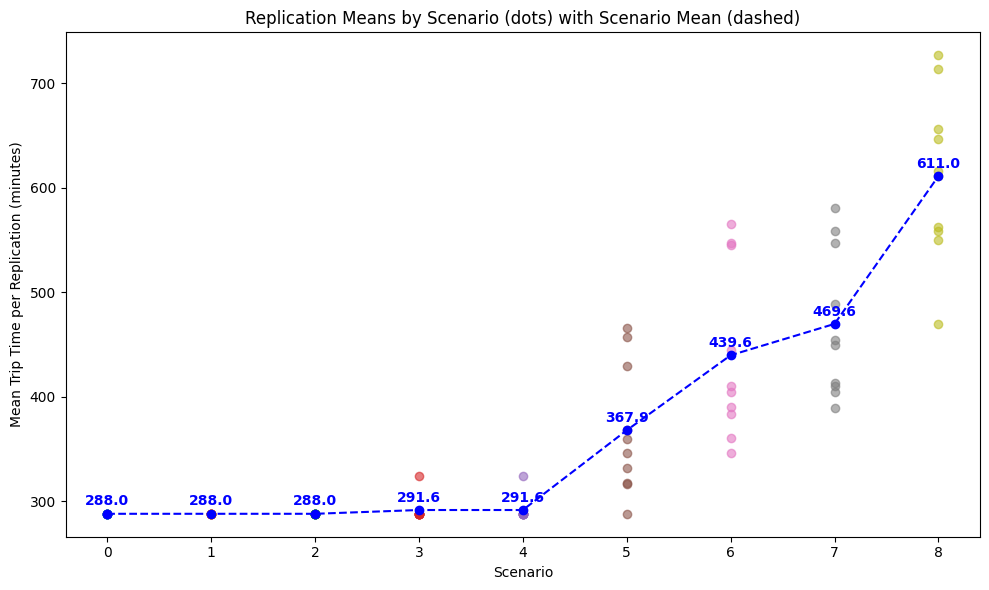

In [21]:
plt.figure(figsize=(10,6))

scenarios = sorted(rep_df["scenario"].unique())

# Plot replication dots
for s in scenarios:
    y = rep_df.loc[rep_df["scenario"] == s, "mean_duration"].values
    x = [s]*len(y)
    plt.scatter(x, y, alpha=0.6)

# Compute scenario means
means = rep_df.groupby("scenario")["mean_duration"].mean()

# Plot mean line
plt.plot(means.index, means.values,
         marker='o',
         linestyle='--',
         color='blue')

# Add mean value labels
for s, m in zip(means.index, means.values):
    plt.text(s,
             m + 8,   # small vertical offset
             f"{m:.1f}",
             ha='center',
             color='blue',
             fontweight='bold')

plt.xticks(scenarios)
plt.xlabel("Scenario")
plt.ylabel("Mean Trip Time per Replication (minutes)")
plt.title("Replication Means by Scenario (dots) with Scenario Mean (dashed)")
plt.tight_layout()
plt.show()

/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_8568/1166574315.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


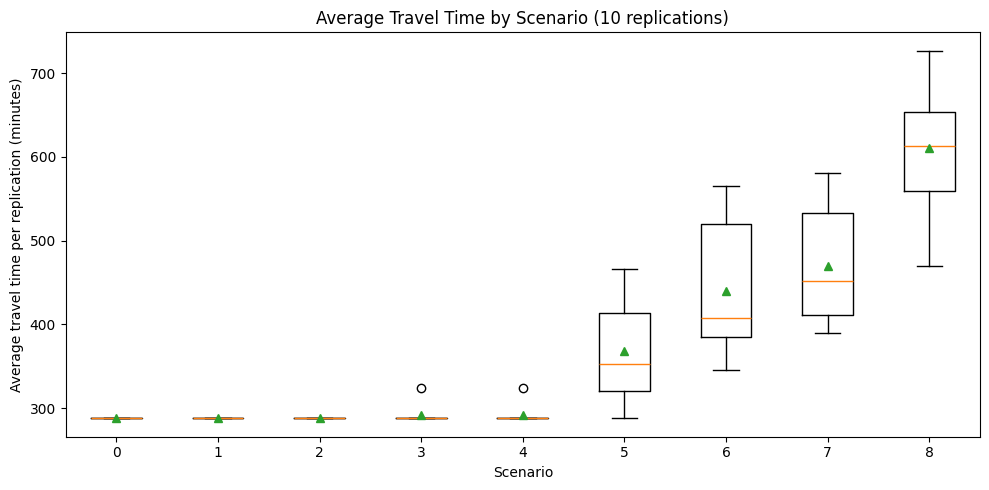

In [22]:
plt.figure(figsize=(10,5))

data = [rep_df.loc[rep_df["scenario"] == s, "mean_duration"] for s in scenarios]

plt.boxplot(
    data,
    labels=scenarios,
    showmeans=True
)

plt.xlabel("Scenario")
plt.ylabel("Average travel time per replication (minutes)")
plt.title("Average Travel Time by Scenario (10 replications)")

plt.tight_layout()
plt.show()

/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_8568/4057016475.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


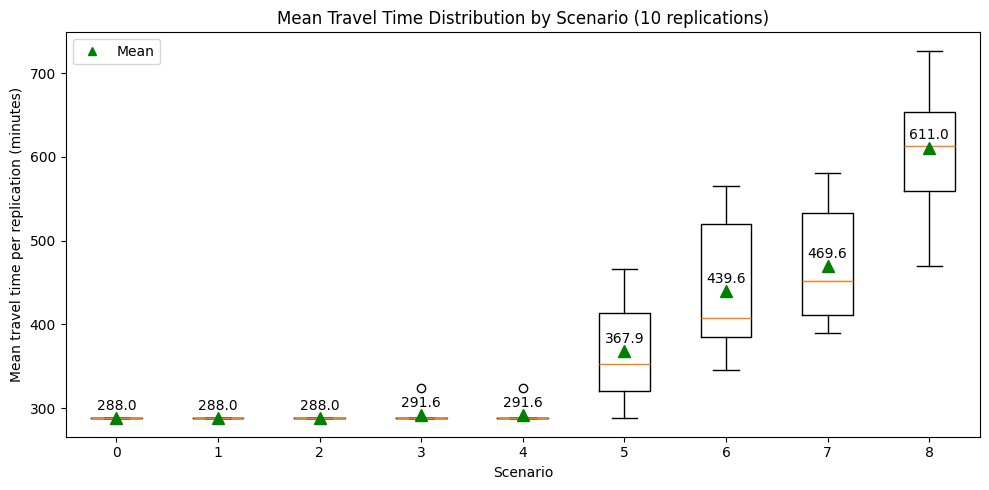

In [23]:
scenarios = sorted(rep_df["scenario"].unique())
data = [rep_df.loc[rep_df["scenario"] == s, "mean_duration"] for s in scenarios]

plt.figure(figsize=(10,5))

# Create boxplot and capture elements
box = plt.boxplot(
    data,
    labels=scenarios,
    showmeans=True,
    meanprops=dict(marker='^',
                   markerfacecolor='green',
                   markeredgecolor='green',
                   markersize=8)
)

# Compute scenario means for labeling
means = [np.mean(d) for d in data]

# Add mean value labels
for i, mean in enumerate(means, start=1):
    plt.text(i,
             mean + 10,   # small vertical offset
             f"{mean:.1f}",
             ha='center',
             color='black')

# Add legend for mean marker
plt.plot([], [], '^', color='green', label='Mean')
plt.legend()

plt.xlabel("Scenario")
plt.ylabel("Mean travel time per replication (minutes)")
plt.title("Mean Travel Time Distribution by Scenario (10 replications)")

plt.tight_layout()
plt.show()

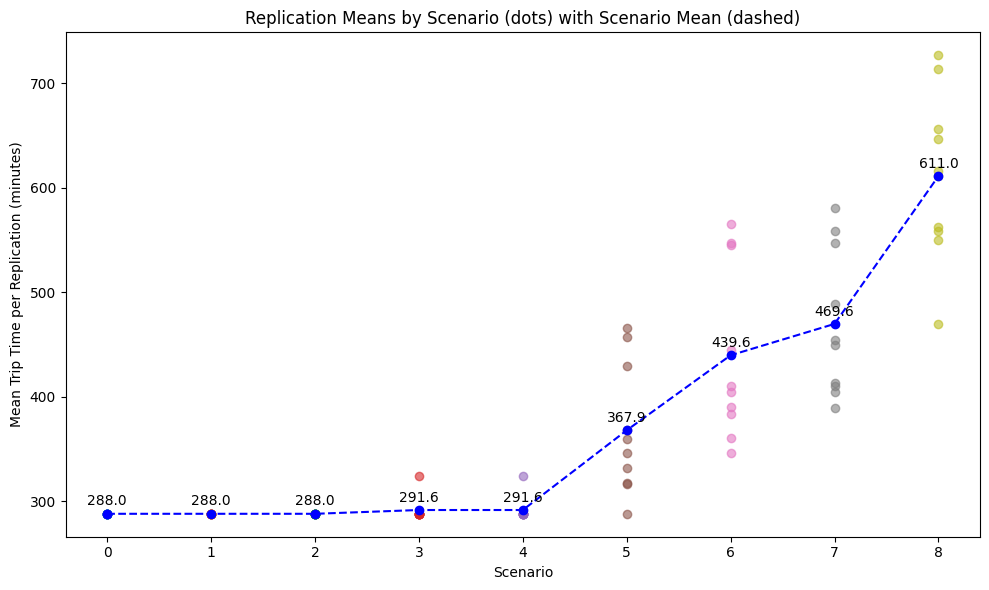

In [24]:
plt.figure(figsize=(10,6))

scenarios = sorted(rep_df["scenario"].unique())

# Plot replication dots
for s in scenarios:
    y = rep_df.loc[rep_df["scenario"] == s, "mean_duration"].values
    x = [s]*len(y)
    plt.scatter(x, y, alpha=0.6)

# Compute scenario means
means = rep_df.groupby("scenario")["mean_duration"].mean()

# Plot mean line (blue like previous)
plt.plot(means.index, means.values,
         marker='o',
         linestyle='--',
         color='blue')

# Add mean value labels (black, not bold)
for s, m in zip(means.index, means.values):
    plt.text(s,
             m + 8,   # small vertical offset
             f"{m:.1f}",
             ha='center',
             color='black')

plt.xticks(scenarios)
plt.xlabel("Scenario")
plt.ylabel("Mean Trip Time per Replication (minutes)")
plt.title("Replication Means by Scenario (dots) with Scenario Mean (dashed)")
plt.tight_layout()
plt.show()

# Bonus Question: Top 5 Bridges to Invest

In [25]:
dfs_bonus = []

for fp in glob.glob(bonus_pattern):
    m = re.search(r"bonus-scenario(\d+)\.csv", os.path.basename(fp))
    scenario = int(m.group(1))
    
    df = pd.read_csv(fp)
    df["scenario"] = scenario
    dfs_bonus.append(df)

bonus_df = pd.concat(dfs_bonus, ignore_index=True)

bonus_df.head()

,lrp,name,total delay,scenario
0,LRP008a,Kachpur bridge,19767.0,8
1,LRP011a,NOYAPARA CULVERT,19859.0,8
2,LRP011b,NAYABARI KASPUR BOX CULVERT,0.0,8
3,LRP012a,NAYABARI BOX CULVERT,50588.0,8
4,LRP013a,MADAN PUR (R),50281.0,8


In [26]:
bonus_filtered = bonus_df[bonus_df["scenario"].between(1,7)].copy()

In [27]:
bridge_summary = (
    bonus_filtered
    .groupby(["lrp", "name"], as_index=False)
    .agg(
        avg_delay=("total delay", "mean"),
        total_delay_all=("total delay", "sum")
    )
    .sort_values("avg_delay", ascending=False)
)

bridge_summary.head(10)

,lrp,name,avg_delay,total_delay_all
45,LRP168a,DHOOM GHAT PC GIRDER,78488.857143,549422.0
7,LRP017c,LANGOLBANDO PC GIDER BRIDGE,39303.714286,275126.0
55,LRP178a,PURPU DURGAPURE BOX CUL,38060.428571,266423.0
8,LRP018a,DARIKANDI BRIDGE (R),21669.571429,151687.0
9,LRP020b,SHADIPUR BOX CULVERT,14334.428571,100341.0
80,LRP232c,Bridge start,9268.428571,64879.0
79,LRP231b,Bridge start,9262.714286,64839.0
68,LRP216a,Bridge start,9262.714286,64839.0
71,LRP218a,Bridge start,9261.142857,64828.0
73,LRP219a,Bridge start,9241.142857,64688.0


In [28]:
nonzero_bridges = bridge_summary[bridge_summary["avg_delay"] > 0].copy()

nonzero_bridges.head()

,lrp,name,avg_delay,total_delay_all
45,LRP168a,DHOOM GHAT PC GIRDER,78488.857143,549422.0
7,LRP017c,LANGOLBANDO PC GIDER BRIDGE,39303.714286,275126.0
55,LRP178a,PURPU DURGAPURE BOX CUL,38060.428571,266423.0
8,LRP018a,DARIKANDI BRIDGE (R),21669.571429,151687.0
9,LRP020b,SHADIPUR BOX CULVERT,14334.428571,100341.0


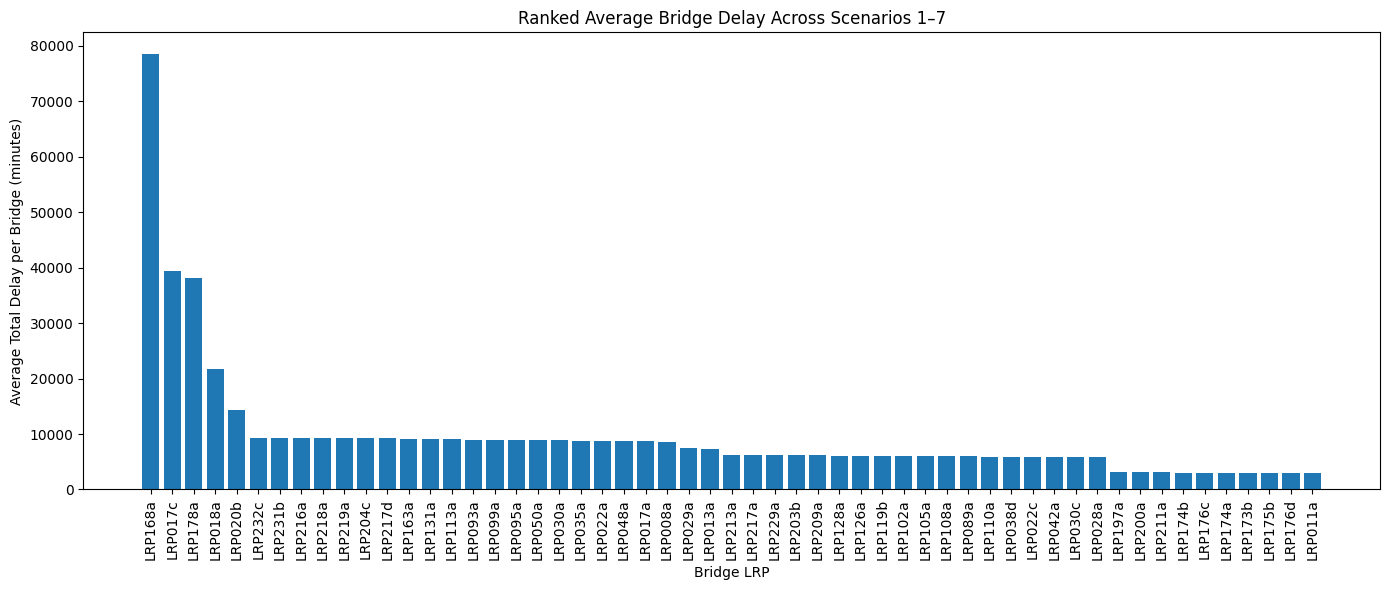

In [29]:
plt.figure(figsize=(14,6))

plt.bar(nonzero_bridges["lrp"], nonzero_bridges["avg_delay"])

plt.xticks(rotation=90)
plt.xlabel("Bridge LRP")
plt.ylabel("Average Total Delay per Bridge (minutes)")
plt.title("Ranked Average Bridge Delay Across Scenarios 1–7")

plt.tight_layout()
plt.show()

In [30]:
top5 = bridge_summary.head(5)
# Create combined label
top5["label"] = top5["lrp"] + " - " + top5["name"]
top5

,lrp,name,avg_delay,total_delay_all,label
45,LRP168a,DHOOM GHAT PC GIRDER,78488.857143,549422.0,LRP168a - DHOOM GHAT PC GIRDER
7,LRP017c,LANGOLBANDO PC GIDER BRIDGE,39303.714286,275126.0,LRP017c - LANGOLBANDO PC GIDER BRIDGE
55,LRP178a,PURPU DURGAPURE BOX CUL,38060.428571,266423.0,LRP178a - PURPU DURGAPURE BOX CUL
8,LRP018a,DARIKANDI BRIDGE (R),21669.571429,151687.0,LRP018a - DARIKANDI BRIDGE (R)
9,LRP020b,SHADIPUR BOX CULVERT,14334.428571,100341.0,LRP020b - SHADIPUR BOX CULVERT


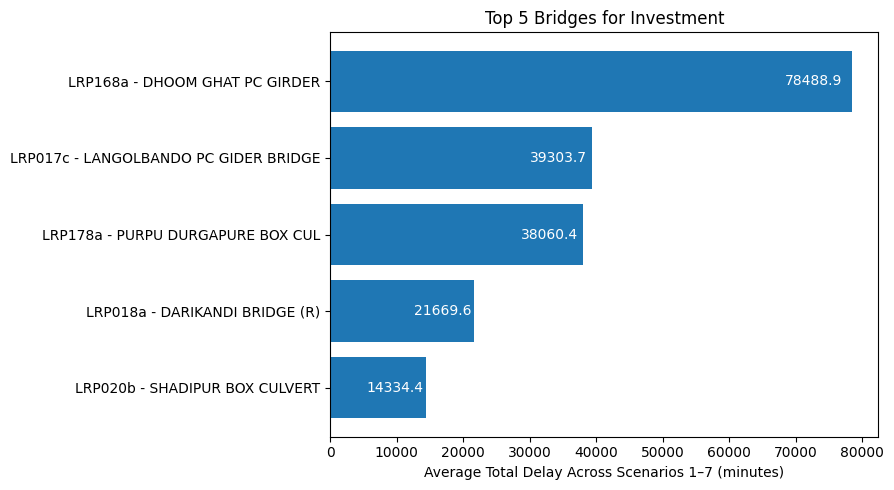

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

bars = plt.barh(top5["label"], top5["avg_delay"])

plt.gca().invert_yaxis()

plt.xlabel("Average Total Delay Across Scenarios 1–7 (minutes)")
plt.title("Top 5 Bridges for Investment")

# Add value labels inside bars
for bar in bars:
    width = bar.get_width()
    plt.text(width * 0.98,  # slightly inside bar
             bar.get_y() + bar.get_height()/2,
             f"{width:.1f}",
             va='center',
             ha='right',
             color='white')   # white for contrast

plt.tight_layout()
plt.show()